In [47]:
import pandas as pd
import numpy as np

In [48]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [49]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [50]:
df.shape

(7043, 21)

In [51]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [52]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [53]:
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    print(f"{col}: {df[col].unique()}")

customerID: ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
gender: ['Female' 'Male']
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
PhoneService: ['No' 'Yes']
MultipleLines: ['No phone service' 'No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['No' 'Yes' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
TotalCharges: ['29.85' '1889.5' '108.15' ... '346.45' '306.6' '6844.5']
Churn: ['No' 'Yes']


In [54]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [55]:
demographics = ['gender','SeniorCitizenn','Partner','Dependents']
accounts = ['tenure','Contract','PaperlessBilling','PaymentMethod','MonthlyCharges','TotalCharges']
services = ['PhoneService','MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
target = 'Churn'
print("Demographics: ", demographics)
print("Accounts: ", accounts)
print("Services: ", services)

Demographics:  ['gender', 'SeniorCitizenn', 'Partner', 'Dependents']
Accounts:  ['tenure', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']
Services:  ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']


In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

In [57]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['Churn_Binary'] = (df['Churn'] == 'Yes').astype(int)

print("Overall Churn rate : ", df['Churn_Binary'].mean().round(3))

Overall Churn rate :  0.265


C:\Users\dell\AppData\Local\Temp\ipykernel_22448\4204459867.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_tenure = df.groupby('TenureGroup')['Churn_Binary'].mean()


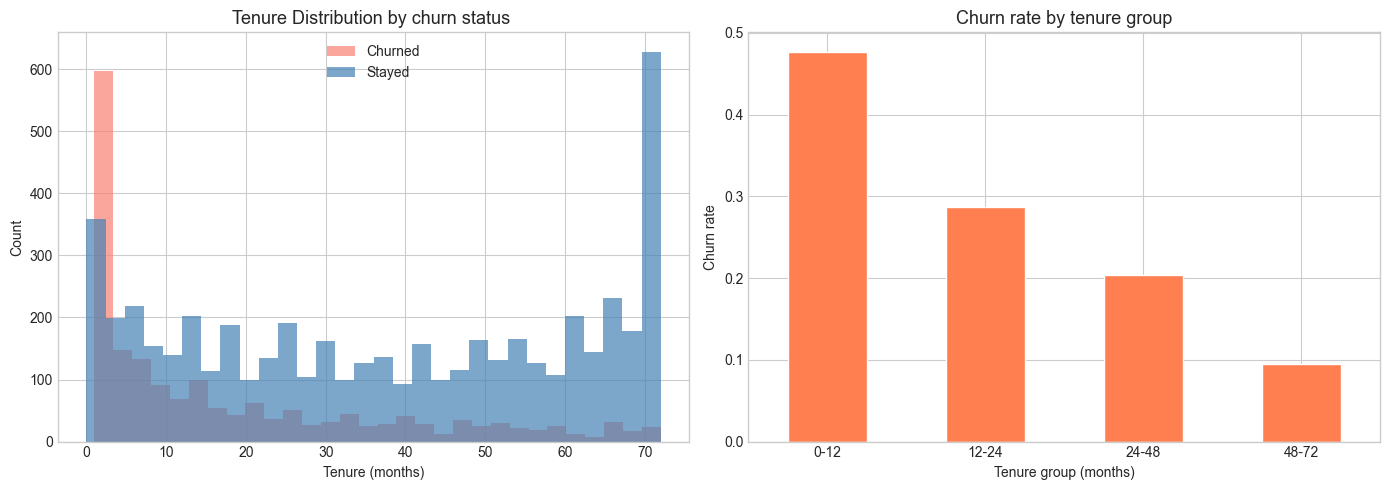

In [58]:
fig, axes = plt.subplots(1,2,figsize=(14,5))

#Tenure distribution by churn
axes[0].set_title("Tenure Distribution by churn status ", fontsize=13)
df[df['Churn']=='Yes']['tenure'].hist(bins=30, alpha=0.7, label='Churned', ax=axes[0], color='salmon')
df[df['Churn']=='No']['tenure'].hist(bins=30, alpha=0.7, label='Stayed', ax=axes[0], color='steelblue')
axes[0].set_xlabel("Tenure (months)")
axes[0].set_ylabel("Count")
axes[0].legend()


#Churn rate by tenure group
df['TenureGroup'] = pd.cut(df['tenure'], bins=[0,12,24,48,72], labels=['0-12','12-24','24-48','48-72'])
churn_by_tenure = df.groupby('TenureGroup')['Churn_Binary'].mean()
churn_by_tenure.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title("Churn rate by tenure group", fontsize=13)
axes[1].set_xlabel("Tenure group (months)")
axes[1].set_ylabel("Churn rate")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('eda_tenure.png',dpi=150)
plt.show()

In [59]:
print("Churn rate by teure group")
print(churn_by_tenure.round(3))

Churn rate by teure group
TenureGroup
0-12     0.477
12-24    0.287
24-48    0.204
48-72    0.095
Name: Churn_Binary, dtype: float64


In [60]:
print("\nCONCLUSION: New customers (0-12 months) churn the most.")
print("This points to an onboarding and early-value problem.")


CONCLUSION: New customers (0-12 months) churn the most.
This points to an onboarding and early-value problem.


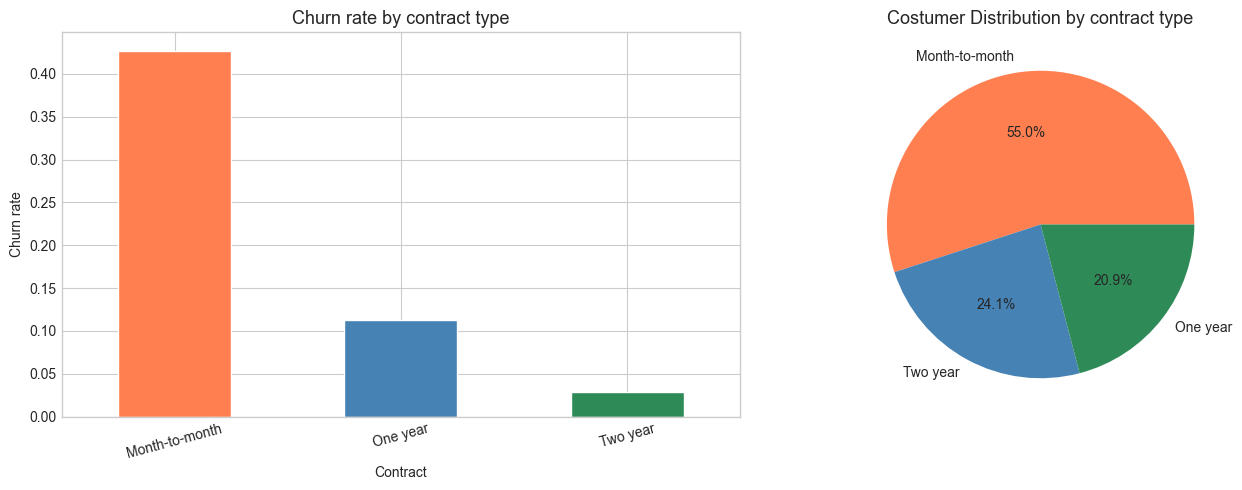

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
churn_by_contract = df.groupby('Contract')['Churn_Binary'].mean().sort_values(ascending=False)
churn_by_contract.plot(kind='bar', ax=axes[0], color=['coral','steelblue','seagreen'], edgecolor='white')
axes[0].set_title("Churn rate by contract type", fontsize=13)
axes[0].set_ylabel("Churn rate")
axes[0].tick_params(axis='x', rotation=15)

df['Contract'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=['coral','steelblue','seagreen'])
axes[1].set_title("Costumer Distribution by contract type", fontsize=13)
axes[1].set_ylabel('')
plt.tight_layout()
plt.savefig('eda_contract.png', dpi=150)
plt.show()

In [62]:
print("Churn rate by contract:")
print(churn_by_contract.round(3))

Churn rate by contract:
Contract
Month-to-month    0.427
One year          0.113
Two year          0.028
Name: Churn_Binary, dtype: float64


In [63]:
print("\nCONCLUSION: Month-to-month customers churn ~3x more than yearly customers.")
print("Converting M2M customers to annual contracts is a key retention lever.")


CONCLUSION: Month-to-month customers churn ~3x more than yearly customers.
Converting M2M customers to annual contracts is a key retention lever.


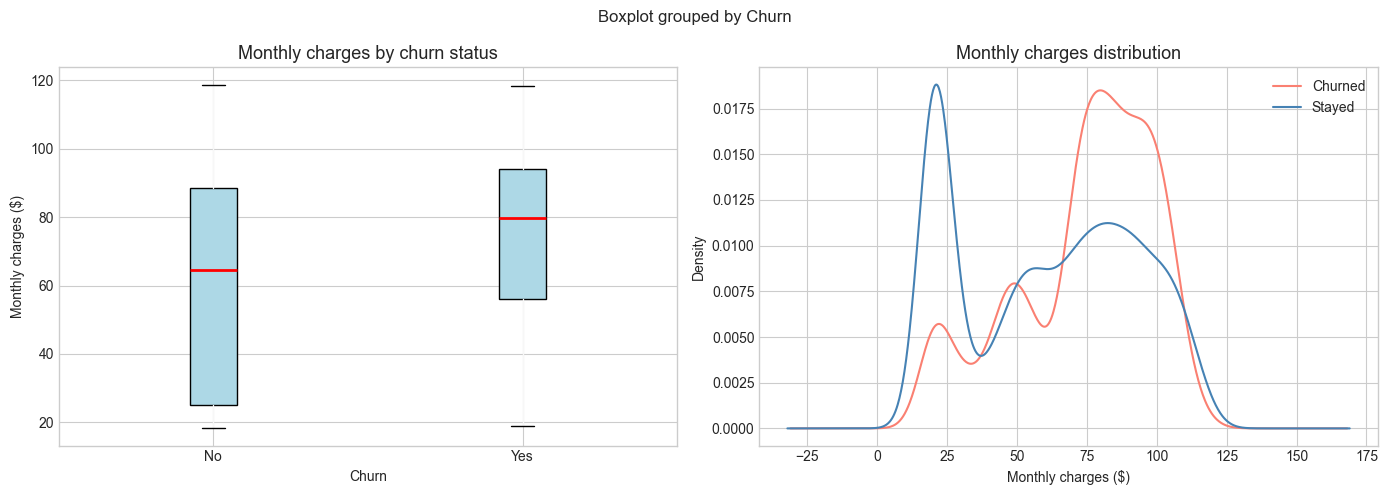

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df.boxplot(column='MonthlyCharges', by='Churn', ax=axes[0],
           patch_artist=True,
           boxprops=dict(facecolor='lightblue'),
           medianprops=dict(color='red', linewidth=2))
axes[0].set_title("Monthly charges by churn status", fontsize=13)
axes[0].set_xlabel("Churn")
axes[0].set_ylabel("Monthly charges ($)")

df[df['Churn']=='Yes']['MonthlyCharges'].plot.kde(ax=axes[1], label='Churned', color='salmon')
df[df['Churn']=='No']['MonthlyCharges'].plot.kde(ax=axes[1], label='Stayed', color='steelblue')
axes[1].set_title("Monthly charges distribution", fontsize=13)
axes[1].set_xlabel("Monthly charges ($)")
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_charges.png', dpi=150)
plt.show()

In [65]:
print("Avg monthly charge - Churned:", df[df['Churn']=='Yes']['MonthlyCharges'].mean().round(2))
print("Avg monthly charge - Stayed:", df[df['Churn']=='No']['MonthlyCharges'].mean().round(2))

Avg monthly charge - Churned: 74.44
Avg monthly charge - Stayed: 61.27


In [66]:
print("\nCONCLUSION: Churned customers pay significantly more on average.")
print("High-charge customers who feel undervalued are highest churn risk.")


CONCLUSION: Churned customers pay significantly more on average.
High-charge customers who feel undervalued are highest churn risk.


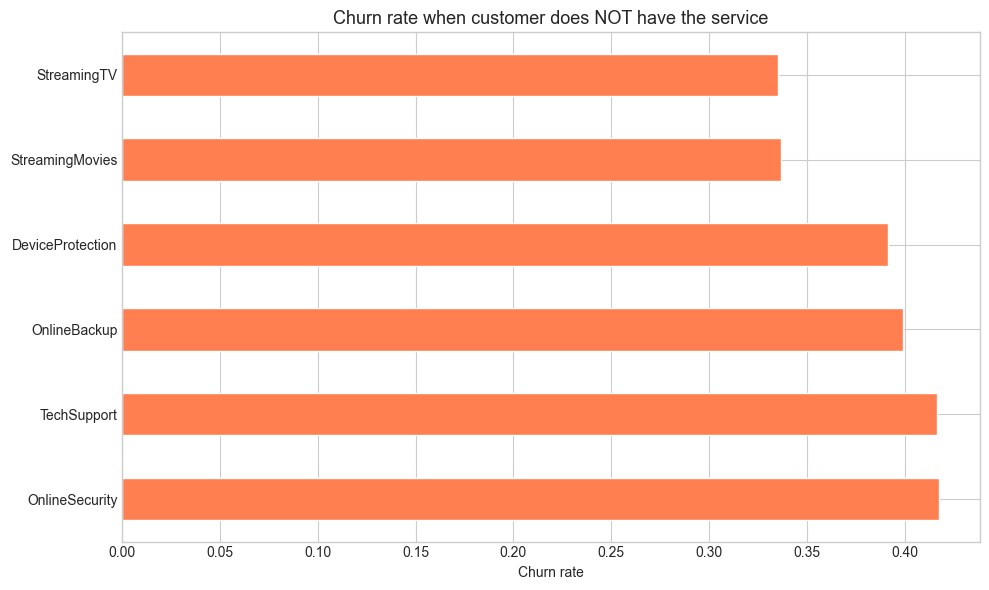

In [67]:
fig, ax = plt.subplots(figsize=(10, 6))
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
churn_rates = {}
for col in service_cols:
    rate = df[df[col]=='No']['Churn_Binary'].mean()
    churn_rates[col] = rate
    
churn_series = pd.Series(churn_rates).sort_values(ascending=False)
churn_series.plot(kind='barh', ax=ax, color='coral', edgecolor='white')
ax.set_title("Churn rate when customer does NOT have the service", fontsize=13)
ax.set_xlabel("Churn rate")

plt.tight_layout()
plt.savefig('eda_services.png', dpi=150)
plt.show()

In [68]:
print("CONCLUSION: Customers without OnlineSecurity and TechSupport churn most.")
print("These are the 'safety net' services — upsell opportunities.")

CONCLUSION: Customers without OnlineSecurity and TechSupport churn most.
These are the 'safety net' services — upsell opportunities.


In [69]:
df_fe = df.copy()
df_fe['AvgMonthlyCharges'] = df_fe['TotalCharges'] / (df_fe['tenure'] + 1)
df_fe['ChargeIncrease'] = df_fe['MonthlyCharges'] - df_fe['AvgMonthlyCharges']
service_cols = ['PhoneService', 'MultipleLines', 'OnlineSecurity',
                'OnlineBackup', 'DeviceProtection', 'TechSupport',
                'StreamingTV', 'StreamingMovies']
for col in service_cols:
    df_fe[col + '_Flag'] = (df_fe[col] == 'Yes').astype(int)

df_fe['TotalServices'] = df_fe[[c + '_Flag' for c in service_cols]].sum(axis=1)
df_fe['HasMultipleServices'] = (df_fe['TotalServices'] >= 3).astype(int)
df_fe['IsHighValue'] = (df_fe['MonthlyCharges'] > df_fe['MonthlyCharges'].quantile(0.75)).astype(int)
df_fe['TenureGroup'] = pd.cut(df_fe['tenure'],bins=[0, 12, 24, 48, 72],labels=['new', 'developing', 'mature', 'loyal'])
df_fe['SeniorNoSupport'] = ((df_fe['SeniorCitizen'] == 1) & (df_fe['TechSupport'] == 'No')).astype(int)
df_fe['HighRiskProfile'] = ((df_fe['Contract'] == 'Month-to-month') & (df_fe['PaymentMethod'] == 'Electronic check')).astype(int)
print("New features created:")
new_features = ['AvgMonthlyCharges', 'ChargeIncrease', 'TotalServices',
                'HasMultipleServices', 'IsHighValue', 'TenureGroup',
                'SeniorNoSupport', 'HighRiskProfile']

df_fe[new_features].describe()

New features created:


,AvgMonthlyCharges,ChargeIncrease,TotalServices,HasMultipleServices,IsHighValue,SeniorNoSupport,HighRiskProfile
count,7032.000000,7032.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,59.083067,5.715142,3.362914,0.578447,0.249610,0.117848,0.262672
std,30.514438,8.861975,2.062031,0.493843,0.432818,0.322450,0.440117
min,9.183333,-6.456667,0.000000,0.000000,0.000000,0.000000,0.000000
25%,26.225944,0.764848,1.000000,0.000000,0.000000,0.000000,0.000000
50%,61.070387,2.438197,3.000000,1.000000,0.000000,0.000000,0.000000
75%,84.877538,6.398437,5.000000,1.000000,0.000000,0.000000,1.000000
max,118.969863,51.225000,8.000000,1.000000,1.000000,1.000000,1.000000


In [75]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

df_fe['TotalCharges'].fillna(0, inplace=True)
df_fe['AvgMonthlyCharges'].fillna(0, inplace=True)
df_fe['ChargeIncrease'].fillna(0, inplace=True)

df_model = df_fe.copy()
df_model['TotalCharges'].fillna(0, inplace=True)
flag_cols = [c + '_Flag' for c in service_cols]
df_model.drop(columns=['customerID', 'Churn', 'TenureGroup'] + flag_cols, inplace=True)
y = df_model.pop('Churn_Binary')
X = df_model

print("Target distribution:")
print(y.value_counts())

Target distribution:
Churn_Binary
0    5174
1    1869
Name: count, dtype: int64


C:\Users\dell\AppData\Local\Temp\ipykernel_22448\1549871147.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_fe['TotalCharges'].fillna(0, inplace=True)
C:\Users\dell\AppData\Local\Temp\ipykernel_22448\1549871147.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example,

In [76]:
print(f"\nClass imbalance ratio: {y.value_counts()[0]/y.value_counts()[1]:.1f}:1")


Class imbalance ratio: 2.8:1


In [77]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [78]:
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # median is robust to outliers
    ('scaler', StandardScaler())
])

# Categorical pipeline: impute first, then encode
cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # fill with mode
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# Combine both pipelines
preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])
print("Categorical:", cat_cols)
print("Numerical:", num_cols)

Categorical: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numerical: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlyCharges', 'ChargeIncrease', 'TotalServices', 'HasMultipleServices', 'IsHighValue', 'SeniorNoSupport', 'HighRiskProfile']


In [79]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Transform
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"\nTrain size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")


Train size: 5634, Test size: 1409


In [74]:
pip install pandas numpy matplotlib seaborn scikit-learn xgboost shap imbalanced-learn streamlit joblib

In [43]:
pip install --upgrade pip


   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 1.8/1.8 MB 7.5 MB/s  0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 25.3
    Uninstalling pip-25.3:
      Successfully uninstalled pip-25.3


In [80]:
import numpy as np
arr = X_train_processed.toarray() if hasattr(X_train_processed, 'toarray') else X_train_processed
print("NaNs in processed train data:", np.isnan(arr).sum())

NaNs in processed train data: 0


In [81]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_processed, y_train)

In [82]:
print("After SMOTE:")
print(f"  Churn=0: {(y_train_balanced==0).sum()}")
print(f"  Churn=1: {(y_train_balanced==1).sum()}")

After SMOTE:
  Churn=0: 4139
  Churn=1: 4139


In [83]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [84]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=200, random_state=42,
                              use_label_encoder=False, eval_metric='logloss')
}

In [85]:
trained_models = {}
for name, model in models.items():
    model.fit(X_train_balanced, y_train_balanced)
    trained_models[name] = model
    print(f"✓ {name} trained")

✓ Logistic Regression trained
✓ Random Forest trained


C:\Users\dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:199: UserWarning: [18:40:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✓ XGBoost trained


In [86]:
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, f1_score, ConfusionMatrixDisplay)

In [87]:
print("=" * 60)
for name, model in trained_models.items():
    y_pred = model.predict(X_test_processed)
    y_prob = model.predict_proba(X_test_processed)[:, 1]

    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    print(f"\n{name}")
    print(f"  F1 Score: {f1:.4f}")
    print(f"  ROC-AUC:  {auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=['Stay', 'Churn']))
print("=" * 60)


Logistic Regression
  F1 Score: 0.6107
  ROC-AUC:  0.8460
              precision    recall  f1-score   support

        Stay       0.90      0.72      0.80      1035
       Churn       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.79      0.74      0.75      1409


Random Forest
  F1 Score: 0.5729
  ROC-AUC:  0.8253
              precision    recall  f1-score   support

        Stay       0.85      0.84      0.84      1035
       Churn       0.57      0.58      0.57       374

    accuracy                           0.77      1409
   macro avg       0.71      0.71      0.71      1409
weighted avg       0.77      0.77      0.77      1409


XGBoost
  F1 Score: 0.5787
  ROC-AUC:  0.8186
              precision    recall  f1-score   support

        Stay       0.85      0.85      0.85      1035
       Churn       0.58      0.57      0.58       374

    accuracy           

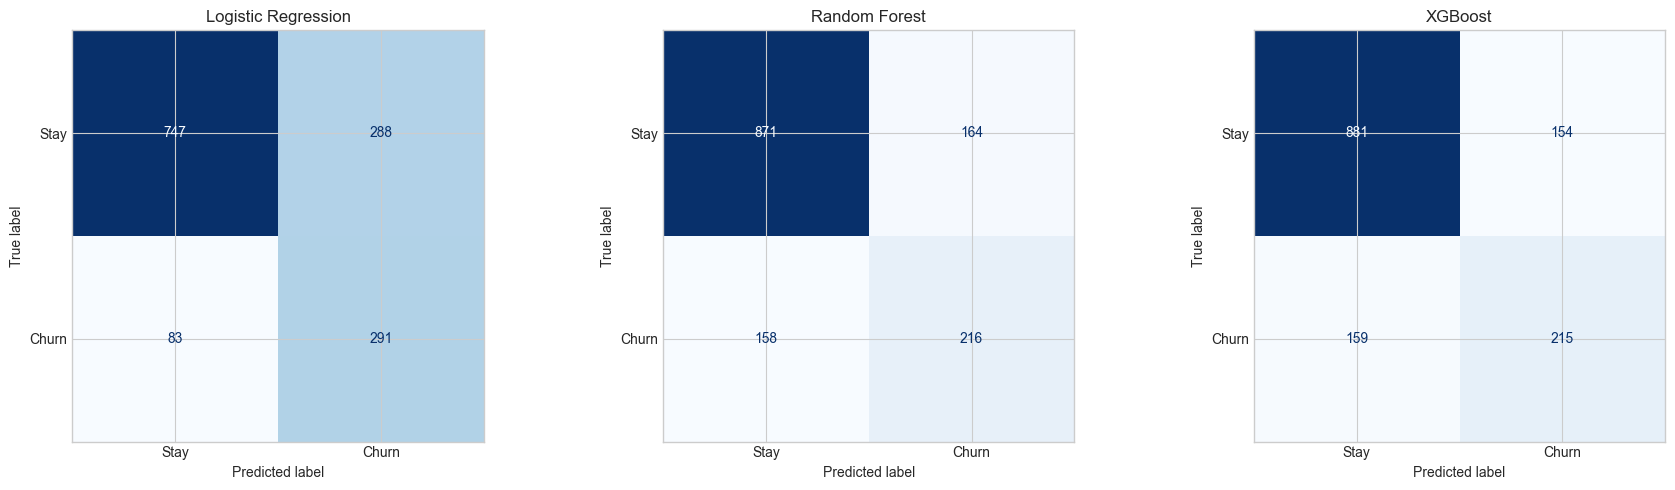

In [88]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, trained_models.items()):
    y_pred = model.predict(X_test_processed)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Stay', 'Churn'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=12)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

In [89]:
print("Business insight: Bottom-left cell = customers who left that we didn't flag.")
print("Each of those is a lost customer we could have tried to retain.")

Business insight: Bottom-left cell = customers who left that we didn't flag.
Each of those is a lost customer we could have tried to retain.


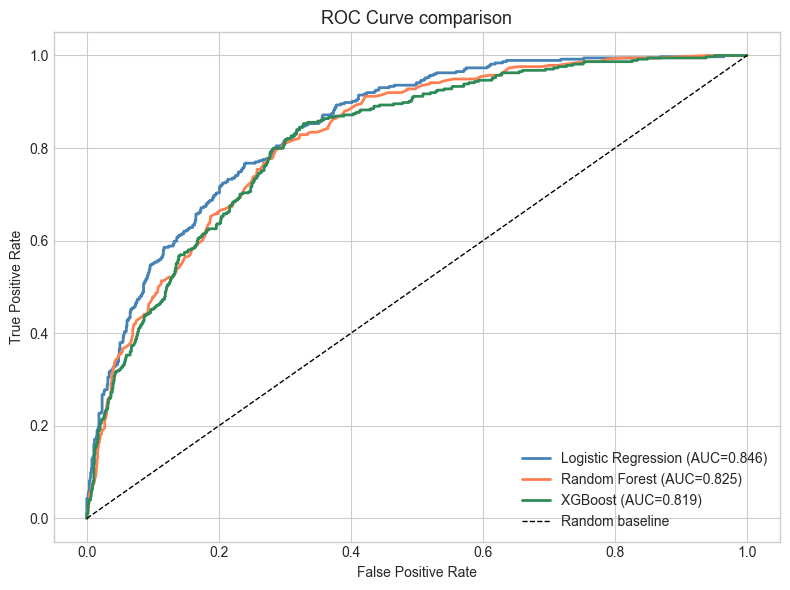

In [90]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(8, 6))

colors = ['steelblue', 'coral', 'seagreen']
for (name, model), color in zip(trained_models.items(), colors):
    y_prob = model.predict_proba(X_test_processed)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, linewidth=2)

ax.plot([0,1],[0,1],'k--', linewidth=1, label='Random baseline')
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve comparison", fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()

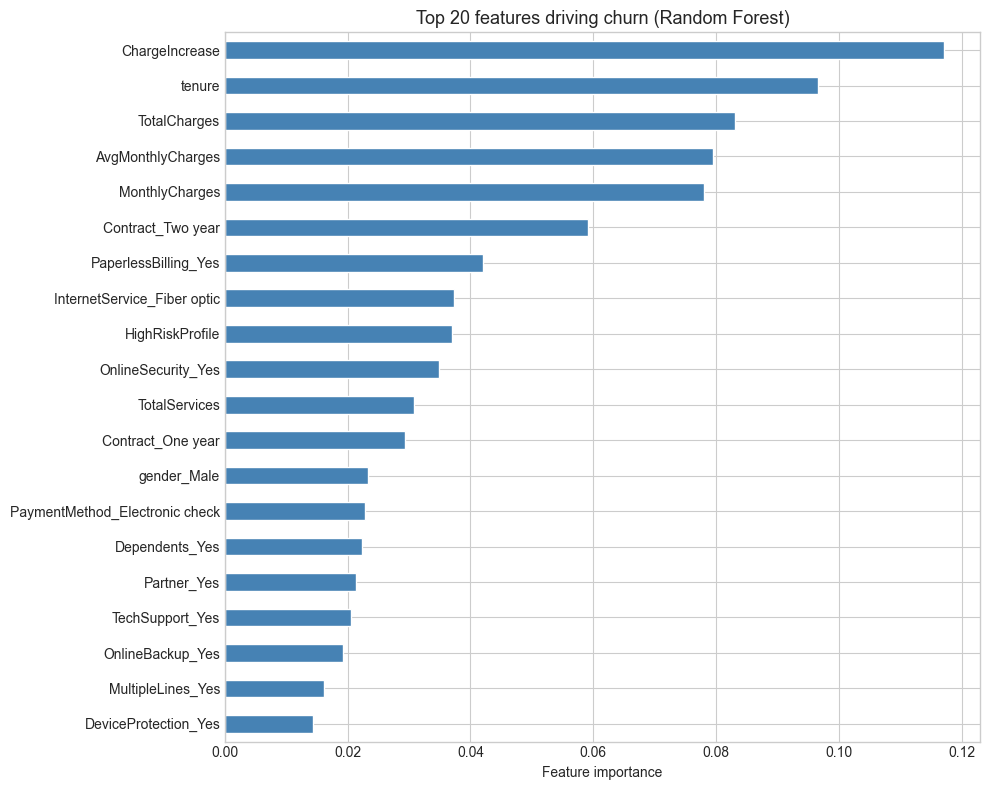

In [91]:
cat_feature_names = (preprocessor
                     .named_transformers_['cat']
                     .get_feature_names_out(cat_cols)
                     .tolist())
all_feature_names = num_cols + cat_feature_names

rf_model = trained_models['Random Forest']
importances = pd.Series(rf_model.feature_importances_, index=all_feature_names)
top20 = importances.nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
top20.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title("Top 20 features driving churn (Random Forest)", fontsize=13)
ax.set_xlabel("Feature importance")
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

In [92]:
print("Top 5 churn drivers:")
for feat, imp in importances.nlargest(5).items():
    print(f"  {feat}: {imp:.4f}")

Top 5 churn drivers:
  ChargeIncrease: 0.1172
  tenure: 0.0966
  TotalCharges: 0.0831
  AvgMonthlyCharges: 0.0795
  MonthlyCharges: 0.0781


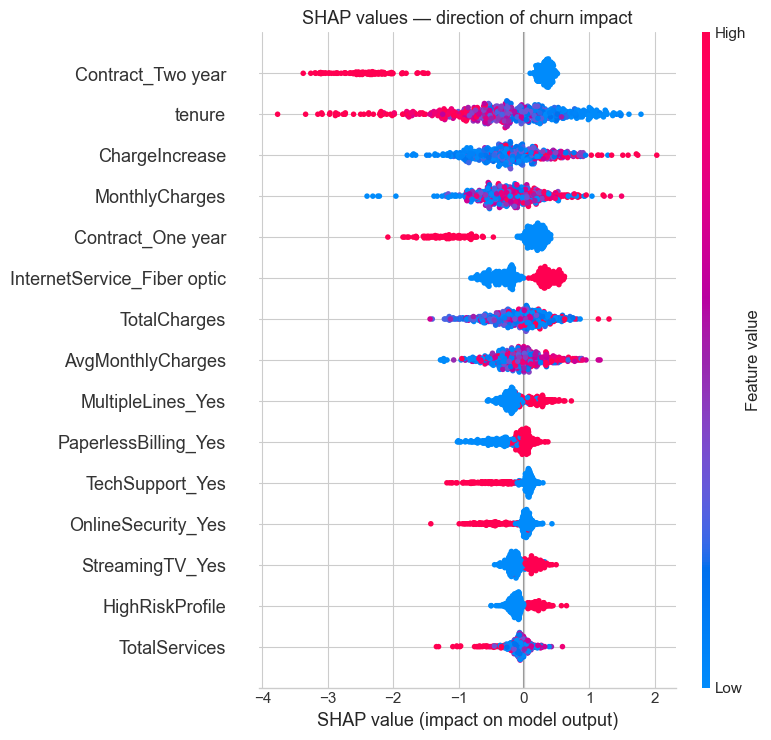

In [93]:
import shap

xgb_model = trained_models['XGBoost']
explainer = shap.TreeExplainer(xgb_model)

X_sample = X_test_processed[:500]
shap_values = explainer.shap_values(X_sample)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample,
                  feature_names=all_feature_names,
                  show=False, max_display=15)
plt.title("SHAP values — direction of churn impact", fontsize=13)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150)
plt.show()

In [94]:
print("\nHow to read SHAP plot:")
print("- Each dot = one customer")
print("- Red = high feature value, Blue = low feature value")
print("- Right side = increases churn probability")


How to read SHAP plot:
- Each dot = one customer
- Red = high feature value, Blue = low feature value
- Right side = increases churn probability


In [95]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [96]:
cluster_features = ['tenure', 'MonthlyCharges', 'TotalServices',
                    'TotalCharges', 'IsHighValue']

df_cluster = df_fe[cluster_features].copy()
df_cluster['TotalCharges'].fillna(0, inplace=True)

scaler = StandardScaler()
X_cluster = scaler.fit_transform(df_cluster)

C:\Users\dell\AppData\Local\Temp\ipykernel_22448\667784347.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cluster['TotalCharges'].fillna(0, inplace=True)


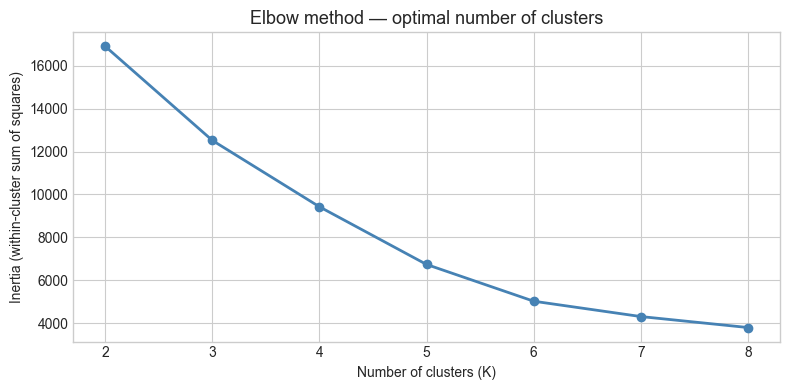

In [98]:
inertias = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, marker='o', color='steelblue', linewidth=2)
plt.title("Elbow method — optimal number of clusters", fontsize=13)
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia (within-cluster sum of squares)")
plt.tight_layout()
plt.savefig('elbow.png', dpi=150)
plt.show()

In [99]:
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df_fe['Segment'] = km_final.fit_predict(X_cluster)

cluster_profile = df_fe.groupby('Segment').agg({
    'tenure': 'mean',
    'MonthlyCharges': 'mean',
    'TotalServices': 'mean',
    'TotalCharges': 'mean',
    'Churn_Binary': 'mean',   # churn rate within segment
    'IsHighValue': 'mean'
}).round(2)

cluster_profile.columns = ['Avg Tenure', 'Avg Monthly $', 'Avg Services',
                           'Avg Total $', 'Churn Rate', 'High Value %']

print("Cluster profiles:")
print(cluster_profile)

Cluster profiles:
         Avg Tenure  Avg Monthly $  Avg Services  Avg Total $  Churn Rate  \
Segment                                                                     
0             27.07          26.04          1.26       681.08        0.15   
1             49.17         101.63          5.75      5045.04        0.28   
2             56.11          72.04          4.79      4029.48        0.10   
3             11.57          72.09          2.88       824.94        0.47   

         High Value %  
Segment                
0                0.00  
1                1.00  
2                0.00  
3                0.08  


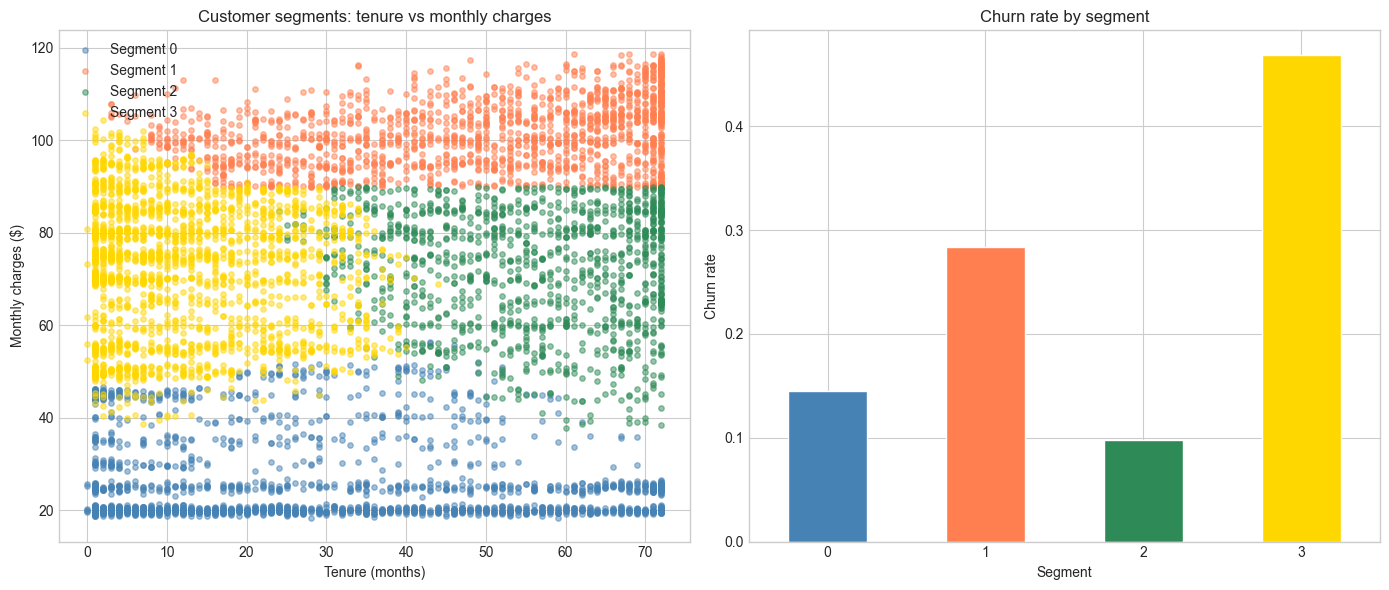

In [100]:
# Visualize segments
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ['steelblue', 'coral', 'seagreen', 'gold']
segment_labels = ['Segment 0', 'Segment 1', 'Segment 2', 'Segment 3']

for seg in range(4):
    mask = df_fe['Segment'] == seg
    axes[0].scatter(df_fe[mask]['tenure'],
                    df_fe[mask]['MonthlyCharges'],
                    c=colors[seg], label=segment_labels[seg],
                    alpha=0.5, s=15)

axes[0].set_xlabel("Tenure (months)")
axes[0].set_ylabel("Monthly charges ($)")
axes[0].set_title("Customer segments: tenure vs monthly charges", fontsize=12)
axes[0].legend()

churn_by_seg = df_fe.groupby('Segment')['Churn_Binary'].mean()
churn_by_seg.plot(kind='bar', ax=axes[1],
                  color=colors, edgecolor='white')
axes[1].set_title("Churn rate by segment", fontsize=12)
axes[1].set_ylabel("Churn rate")
axes[1].set_xlabel("Segment")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('segments.png', dpi=150)
plt.show()

In [101]:
segment_names = {}
for seg in range(4):
    row = cluster_profile.loc[seg]
    print(f"\nSegment {seg}:")
    print(f"  Tenure={row['Avg Tenure']:.0f}m, Monthly=${row['Avg Monthly $']:.0f}, "
          f"Services={row['Avg Services']:.1f}, Churn={row['Churn Rate']:.0%}")


Segment 0:
  Tenure=27m, Monthly=$26, Services=1.3, Churn=15%

Segment 1:
  Tenure=49m, Monthly=$102, Services=5.8, Churn=28%

Segment 2:
  Tenure=56m, Monthly=$72, Services=4.8, Churn=10%

Segment 3:
  Tenure=12m, Monthly=$72, Services=2.9, Churn=47%


In [104]:
print("""
         BUSINESS RECOMMENDATIONS — CHURN REDUCTION          


FINDING 1: Month-to-month customers churn ~3x more than annual
ACTION:    → Offer 1-2 month free if they switch to annual contract
           → Show M2M customers the cost savings of annual plans
           → Target within first 3 months (before disengagement)

FINDING 2: New customers (0-12m) churn most
ACTION:    → Create a 90-day onboarding program
           → Assign a customer success touch-point at month 1, 3, 6
           → Offer a "First Year Guarantee" to reduce anxiety

FINDING 3: High monthly charge + no OnlineSecurity = high risk
ACTION:    → Bundle OnlineSecurity into premium plans
           → Run a "Security Audit" campaign for high-payers
           → Offer 3-month free trial of OnlineSecurity

FINDING 4: Electronic check users churn more
ACTION:    → Incentivize auto-pay setup (e.g., $5 off/month)
           → Auto-pay customers are harder to cancel passively
           → Send payment method switch prompts at contract renewal

FINDING 5: Senior citizens without TechSupport churn more
ACTION:    → Create a "Senior Care" package with priority support
           → Offer TechSupport at a discount for 65+ customers
           → Proactive monthly check-in calls for this segment

SEGMENTATION ACTIONS:
  At-Risk Newcomers  → Immediate outreach, special retention offer
  Loyal Basic Users  → Upsell campaign, show value of adding services
  Engaged Power Users → Loyalty rewards, referral program
  Champion Customers → VIP program, early access to new products
""")


         BUSINESS RECOMMENDATIONS — CHURN REDUCTION          


FINDING 1: Month-to-month customers churn ~3x more than annual
ACTION:    → Offer 1-2 month free if they switch to annual contract
           → Show M2M customers the cost savings of annual plans
           → Target within first 3 months (before disengagement)

FINDING 2: New customers (0-12m) churn most
ACTION:    → Create a 90-day onboarding program
           → Assign a customer success touch-point at month 1, 3, 6
           → Offer a "First Year Guarantee" to reduce anxiety

FINDING 3: High monthly charge + no OnlineSecurity = high risk
ACTION:    → Bundle OnlineSecurity into premium plans
           → Run a "Security Audit" campaign for high-payers
           → Offer 3-month free trial of OnlineSecurity

FINDING 4: Electronic check users churn more
ACTION:    → Incentivize auto-pay setup (e.g., $5 off/month)
           → Auto-pay customers are harder to cancel passively
           → Send payment method switch prompt

In [103]:
def get_churn_risk_score(customer_data: dict, model, preprocessor) -> dict:
    """
    Takes a customer record and returns churn probability + risk tier.
    WHY: This can be called from a CRM system to flag at-risk customers daily.
    """
    df_input = pd.DataFrame([customer_data])
    X_processed = preprocessor.transform(df_input)
    prob = model.predict_proba(X_processed)[0][1]

    if prob >= 0.7:
        risk_tier = "HIGH — Immediate action needed"
        action = "Personal call from retention team"
    elif prob >= 0.4:
        risk_tier = "MEDIUM — Monitor closely"
        action = "Targeted email with loyalty offer"
    else:
        risk_tier = "LOW — Maintain relationship"
        action = "Include in standard loyalty program"

    return {
        'churn_probability': round(prob, 3),
        'risk_tier': risk_tier,
        'recommended_action': action
    }

# Example usage
sample_customer = X_test.iloc[0].to_dict()
result = get_churn_risk_score(sample_customer, trained_models['XGBoost'], preprocessor)
print("Sample customer churn risk assessment:")
for k, v in result.items():
    print(f"  {k}: {v}")

Sample customer churn risk assessment:
  churn_probability: 0.008999999612569809
  risk_tier: LOW — Maintain relationship
  recommended_action: Include in standard loyalty program
